In [3]:
!pip list

Package                  Version
------------------------ --------------
absl-py                  2.1.0
apturl                   0.5.2
asttokens                3.0.0
astunparse               1.6.3
attrs                    24.3.0
beautifulsoup4           4.12.3
blinker                  1.7.0
Brlapi                   0.8.5
Brotli                   1.1.0
certifi                  2023.11.17
cffi                     1.17.1
chardet                  5.2.0
click                    8.1.6
colorama                 0.4.6
comm                     0.2.2
command-not-found        0.3
configobj                5.0.8
contourpy                1.3.1
cryptography             41.0.7
cupshelpers              1.0
cycler                   0.12.1
dbus-python              1.3.2
debugpy                  1.8.11
decorator                5.1.1
defer                    1.0.6
deprecation              2.0.7
distro                   1.9.0
dlib                     19.24.5
executing                2.1.0
eyed3              

In [4]:
!pip install opencv-python matplotlib imageio tensorflow pandas

Defaulting to user installation because normal site-packages is not writeable


In [5]:
import os
import cv2
import mediapipe as mp
import tensorflow as tf
import math
import time
import numpy as np
from typing import List
from matplotlib import pyplot as plt
import imageio

2025-01-18 03:36:04.058101: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1737171364.071306  527620 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1737171364.075019  527620 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-01-18 03:36:04.089394: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [88]:
CWD_DIR = "/home/tymstr/Documents/GitHub/speaker-diarization/Backend/FacialLandmarks/SpeakingFacesDataset/SubjectOne/"
CWD_DIR2 = "/home/tymstr/Documents/GitHub/speaker-diarization/Backend/FacialLandmarks/SpeakingFacesDataset/SubjectThree/"
MOUTH_LANDMARKS = [0, 267, 269, 270, 409, 306, 375, 321, 405, 314, 17, 84, 181, 91, 146, 61, 185, 40, 39,
                                37]
All_MOUTH_LANDMARKS = []

In [109]:
def InjestImages(cwd_dir):
    images = []
    for file in os.listdir(cwd_dir):
        filename = os.fsdecode(file)
        images.append(filename)

    arr = np.array(images)

    return np.sort(arr)

InjestImages(CWD_DIR)

array(['1_1_2_1_574_100_2.png', '1_1_2_1_574_101_2.png',
       '1_1_2_1_574_102_2.png', '1_1_2_1_574_103_2.png',
       '1_1_2_1_574_104_2.png', '1_1_2_1_574_105_2.png',
       '1_1_2_1_574_106_2.png', '1_1_2_1_574_107_2.png',
       '1_1_2_1_574_108_2.png', '1_1_2_1_574_109_2.png',
       '1_1_2_1_574_10_2.png', '1_1_2_1_574_110_2.png',
       '1_1_2_1_574_111_2.png', '1_1_2_1_574_112_2.png',
       '1_1_2_1_574_113_2.png', '1_1_2_1_574_114_2.png',
       '1_1_2_1_574_115_2.png', '1_1_2_1_574_116_2.png',
       '1_1_2_1_574_11_2.png', '1_1_2_1_574_12_2.png',
       '1_1_2_1_574_13_2.png', '1_1_2_1_574_14_2.png',
       '1_1_2_1_574_15_2.png', '1_1_2_1_574_16_2.png',
       '1_1_2_1_574_17_2.png', '1_1_2_1_574_18_2.png',
       '1_1_2_1_574_19_2.png', '1_1_2_1_574_1_2.png',
       '1_1_2_1_574_20_2.png', '1_1_2_1_574_21_2.png',
       '1_1_2_1_574_22_2.png', '1_1_2_1_574_23_2.png',
       '1_1_2_1_574_24_2.png', '1_1_2_1_574_25_2.png',
       '1_1_2_1_574_26_2.png', '1_1_2_1_574_27_2.

In [8]:
mpDraw = mp.solutions.drawing_utils
mpFaceMesh = mp.solutions.face_mesh
faceMesh = mpFaceMesh.FaceMesh(max_num_faces=2)
drawSpec = mpDraw.DrawingSpec(thickness=1, circle_radius=1)


I0000 00:00:1737171365.885127  527620 gl_context_egl.cc:85] Successfully initialized EGL. Major : 1 Minor: 5
I0000 00:00:1737171365.886997  533552 gl_context.cc:369] GL version: 3.2 (OpenGL ES 3.2 Mesa 24.0.9-0ubuntu0.1), renderer: NV194


In [13]:
def FindMouth(img, output):
    points = []
    dict = {}
    results = faceMesh.process(img)
    if results.multi_face_landmarks:
        for faceLms in results.multi_face_landmarks:
            # mpDraw.draw_landmarks(img, faceLms, mpFaceMesh.FACEMESH_CONTOURS, drawSpec, drawSpec)
            for id,lm in enumerate(faceLms.landmark):
                image_height, image_width, image_channels = img.shape
                x,y = int(lm.x*image_width), int(lm.y*image_height)
                if id in MOUTH_LANDMARKS:
                    points.append((x,y))
                    dict[id] = (x,y)
     
    if output == "points":            
        return points
    else:
        return dict
    



In [9]:
def CalculateDistances(dict):
    newdict = {}
    for item, value in dict.items():
        newdict[item] = []
        for jtem, jvalue in dict.items():
            if jtem != item:
                newdict[item].append(math.dist(value, jvalue)) 
    print(newdict)

W0000 00:00:1737067766.681506  280680 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


In [54]:
def ShowVideo():
    image_array = InjestImages(CWD_DIR)
    for i in range(1):
            img = cv2.imread(CWD_DIR + image_array[i])
            mouthpoints = FindMouth(img, "points")# Return a list of mouth coordinates for a image
            for mouthpoint in mouthpoints:
                cv2.circle(img, mouthpoint, 1, (255, 0, 0), 1)
            

            cv2.putText(img, f'Frame: {int(i)}', (20,70), cv2.FONT_HERSHEY_PLAIN,
                        3, (0,255,0), 3)
            cv2.imshow("image", img)
            time.sleep(0.2)
            
            cv2.waitKey(1)

    cv2.waitKey(0)
    cv2.destroyAllWindows()

ShowVideo()

In [89]:
from random import randrange

def load_video(path:str, talking:bool) -> list[float]:
    image_array = InjestImages(path)
    frames = []
    if talking:
        for i in range(len(image_array)):
            frame = cv2.imread(path + image_array[i])
            mouthpoints = FindMouth(frame, "points")
            x,y = mouthpoints[0]
            frame = tf.image.rgb_to_grayscale(frame)
            frames.append(frame[y-40:y+60,x-50:x+50,:])
    else:
        for i in range(len(image_array)):
            frame = cv2.imread(path + image_array[randrange(10)])
            mouthpoints = FindMouth(frame, "points")
            x,y = mouthpoints[0]
            frame = tf.image.rgb_to_grayscale(frame)
            frames.append(frame[y-40:y+60,x-50:x+50,:])
            
    return tf.cast(frames, tf.float32)



In [90]:
talking_frames = load_video(CWD_DIR, True)
test_talking = load_video(CWD_DIR2, True)

In [91]:

silent_frames = load_video(CWD_DIR, False)
test_silent = load_video(CWD_DIR2, False)

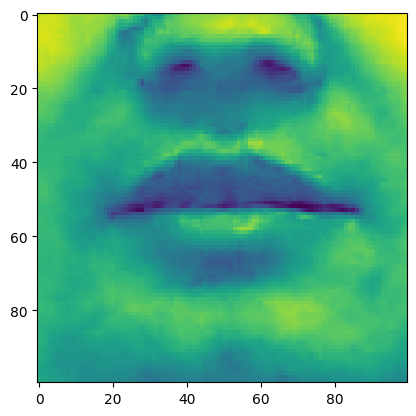

In [94]:
plt.imshow(talking_frames[5])

In [100]:
import pandas as pd
data_train = pd.DataFrame(zip(talking_frames+silent_frames, [1]*talking_frames+[0]*silent_frames), columns=['frame', 'label'])
data_test = pd.DataFrame(zip(test_talking+test_silent, [1]*test_talking+[0]*test_silent), columns=['frame', 'label'])
# pad data
# all_data = talking_frames+silent_frames+test_talking+test_silent

In [101]:
from tensorflow.keras.models import Sequential 
from tensorflow.keras.layers import Conv3D, LSTM, Dense, Dropout, Bidirectional, MaxPool3D, Activation, Reshape, SpatialDropout3D, BatchNormalization, TimeDistributed, Flatten
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint, LearningRateScheduler

In [103]:
model = Sequential()
model.add(Conv3D(128, 3, input_shape=(120,100,100,1), padding='same'))
model.add(Activation('relu'))
model.add(MaxPool3D((1,2,2)))

model.add(Conv3D(256, 3, padding='same'))
model.add(Activation('relu'))
model.add(MaxPool3D((1,2,2)))

model.add(Conv3D(75, 3, padding='same'))
model.add(Activation('relu'))
model.add(MaxPool3D((1,2,2)))

model.add(TimeDistributed(Flatten()))

model.add(Bidirectional(LSTM(128, kernel_initializer='Orthogonal', return_sequences=True)))
model.add(Dropout(.5))

model.add(Bidirectional(LSTM(128, kernel_initializer='Orthogonal', return_sequences=True)))
model.add(Dropout(.5))

model.add(Dense(1, activation='sigmoid'))


In [104]:
model.summary()


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv3d_3 (Conv3D)               │ (None, 120, 100, 100,  │         3,584 │
│                                 │ 128)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 120, 100, 100,  │             0 │
│                                 │ 128)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling3d_3 (MaxPooling3D)  │ (None, 120, 50, 50,    │             0 │
│                                 │ 128)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3d_4 (Conv3D)               │ (None, 120, 50, 50,    │       884,992 │
│                                 │ 256)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 120, 50, 50,    │             0 │
│                                 │ 256)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling3d_4 (MaxPooling3D)  │ (None, 120, 25, 25,    │             0 │
│                                 │ 256)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3d_5 (Conv3D)               │ (None, 120, 25, 25,    │       518,475 │
│                                 │ 75)                    │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_5 (Activation)       │ (None, 120, 25, 25,    │             0 │
│                                 │ 75)                    │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling3d_5 (MaxPooling3D)  │ (None, 120, 12, 12,    │             0 │
│                                 │ 75)                    │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_1              │ (None, 120, 10800)     │             0 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_2 (Bidirectional) │ (None, 120, 256)       │    11,191,296 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 120, 256)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_3 (Bidirectional) │ (None, 120, 256)       │       394,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 120, 256)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 120, 1)         │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,992,844 (49.56 MB)

 Trainable params: 12,992,844 (49.56 MB)

 Non-trainable params: 0 (0.00 B)

In [108]:
x = test_talking[0]
y = model(x)

ValueError: Exception encountered when calling Sequential.call().

[1mInvalid input shape for input [[[ 94.]
  [ 94.]
  [ 93.]
  ...
  [ 95.]
  [ 94.]
  [ 95.]]

 [[ 95.]
  [ 94.]
  [ 94.]
  ...
  [ 98.]
  [ 98.]
  [ 98.]]

 [[ 94.]
  [ 93.]
  [ 92.]
  ...
  [101.]
  [100.]
  [100.]]

 ...

 [[ 13.]
  [ 13.]
  [ 12.]
  ...
  [ 45.]
  [ 45.]
  [ 44.]]

 [[ 14.]
  [ 14.]
  [ 14.]
  ...
  [ 43.]
  [ 42.]
  [ 43.]]

 [[ 14.]
  [ 15.]
  [ 15.]
  ...
  [ 42.]
  [ 41.]
  [ 39.]]]. Expected shape (None, 120, 100, 100, 1), but input has incompatible shape (100, 100, 1)[0m

Arguments received by Sequential.call():
  • inputs=tf.Tensor(shape=(100, 100, 1), dtype=float32)
  • training=None
  • mask=None